<a href="https://colab.research.google.com/github/AWADKILLERB/jupyter/blob/master/Microscopic_Valley_Toolkit_Part4_VerifiedBondCoherence_ipynb_(1)_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Microscopic Valley Toolkit — Part 4: Bond Coherence with the Verified Hamiltonian

**Title:** Microscopic Theory of Valley Splitting in Silicon
**Author:** Awad Mohamed
**Supervisor (Prospective):** Dr. Mark Friesen (University of Wisconsin–Madison)
**Project Status:** Stage IV — Robustness Check of the Bond Coherence Discovery

---

## Purpose of this notebook

Part 2 discovered a non-monotonic relationship between interface roughness and a
measure of coherence among the four microscopic bonds of a silicon atom, using an
illustrative tight-binding model with hand-picked parameters and a manually injected
valley location.

Part 3 built and thoroughly verified a much more realistic tight-binding
Hamiltonian, with parameters taken directly from the published literature and a
valley location derived from the calculation itself rather than assumed.

This notebook repeats the entire Part 2 analysis using the verified Hamiltonian from
Part 3, in order to answer a single question: was the earlier discovery a genuine
physical pattern, or an artifact of the illustrative parameters used at the time.


## Chapter 1 — The Verified Foundation (carried forward from Part 3)

Every quantity in this section was independently checked in Part 3: the Hamiltonian
agrees with a reference implementation to machine precision, the band gap matches
the experimental value closely, and the valley location is confirmed consistent
across the three crystal axes as required by symmetry.


In [ ]:

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

params_sp3s = {
    "Es": -4.2000, "Ep": 1.7150, "Ess": 6.6850,
    "Vss_sigma": -8.3000, "Vsp_sigma": 5.7292, "Vssp_sigma": 5.3749,
    "a": 5.4310000000,
}
Vxx, Vxy = 1.7150, 4.5750
params_sp3s["Vpp_pi"] = Vxx - Vxy
params_sp3s["Vpp_sigma"] = Vxx + 2*Vxy
a = params_sp3s["a"]

def phase_factors(kx, ky, kz, a):
    kxp, kyp, kzp = kx*a/4.0, ky*a/4.0, kz*a/4.0
    g0 = np.cos(kxp)*np.cos(kyp)*np.cos(kzp) - np.sin(kxp)*np.sin(kyp)*np.sin(kzp)*1j
    g1 = -np.cos(kxp)*np.sin(kyp)*np.sin(kzp) + np.sin(kxp)*np.cos(kyp)*np.cos(kzp)*1j
    g2 = -np.sin(kxp)*np.cos(kyp)*np.sin(kzp) + np.cos(kxp)*np.sin(kyp)*np.cos(kzp)*1j
    g3 = -np.sin(kxp)*np.sin(kyp)*np.cos(kzp) + np.cos(kxp)*np.cos(kyp)*np.sin(kzp)*1j
    return g0, g1, g2, g3

def H_k_sp3s(kx, ky, kz, p):
    Es, Ep, Ess = p["Es"], p["Ep"], p["Ess"]
    Vss, Vsp, Vssp = p["Vss_sigma"], p["Vsp_sigma"], p["Vssp_sigma"]
    Vpp_s, Vpp_p = p["Vpp_sigma"], p["Vpp_pi"]
    a = p["a"]
    Vxx_ = (Vpp_s + 2*Vpp_p)/3.0; Vxy_ = (Vpp_s - Vpp_p)/3.0
    g0, g1, g2, g3 = phase_factors(kx, ky, kz, a)
    HAA = np.diag([Es, Ep, Ep, Ep, Ess]); HBB = np.diag([Es, Ep, Ep, Ep, Ess])
    HAB = np.array([
        [Vss*g0,   Vsp*g1,   Vsp*g2,   Vsp*g3,   0],
        [-Vsp*g1,  Vxx_*g0,  Vxy_*g3,  Vxy_*g2,  -Vssp*g1],
        [-Vsp*g2,  Vxy_*g3,  Vxx_*g0,  Vxy_*g1,  -Vssp*g2],
        [-Vsp*g3,  Vxy_*g2,  Vxy_*g1,  Vxx_*g0,  -Vssp*g3],
        [0,        Vssp*g1,  Vssp*g2,  Vssp*g3,  0]
    ], dtype=complex)
    return np.block([[HAA, HAB],[HAB.conj().T, HBB]])

X_abs = 2*np.pi/a
k0 = 0.7307 * X_abs   # self-derived, verified in Part 3
band_idx = 4

Hp = H_k_sp3s(0, 0,  k0, params_sp3s)
Hm = H_k_sp3s(0, 0, -k0, params_sp3s)
evals_p, evecs_p = la.eigh(Hp)
evals_m, evecs_m = la.eigh(Hm)
u_plus  = evecs_p[:, band_idx]
u_minus = evecs_m[:, band_idx]

assert np.isclose(evals_p[band_idx], evals_m[band_idx], atol=1e-10)
assert np.isclose(np.vdot(u_plus,u_plus).real, 1.0, atol=1e-12)
assert np.isclose(np.vdot(u_minus,u_minus).real, 1.0, atol=1e-12)
print(f"self-derived valley wavevector: {k0:.6f} inverse angstrom")
print("valley states extracted, normalized, and confirmed equal in energy")


self-derived valley wavevector: 0.845355 inverse angstrom
valley states extracted, normalized, and confirmed equal in energy


## Chapter 2 — Extended Bond Matrix and the Bond Correlation Object

The single-bond hopping matrix is extended here to include the extra orbital, and
the four bond amplitudes are built exactly as in Part 2. This quantity is used only
to study the internal correlation structure among the four bonds, not to compute an
absolute physical coupling strength directly, following the methodological
clarification recorded in Part 3.


In [ ]:

def slater_koster_matrix_sp3s(l, m, n, p):
    Vsp = p["Vsp_sigma"]; Vpp_s = p["Vpp_sigma"]; Vpp_p = p["Vpp_pi"]; Vssp = p["Vssp_sigma"]
    d = np.array([l, m, n])
    M_pp = Vpp_p*np.eye(3) + (Vpp_s - Vpp_p)*np.outer(d, d)
    M = np.zeros((5,5), dtype=complex)
    M[0,0] = p["Vss_sigma"]
    M[0,1:4] = Vsp*d; M[1:4,0] = -Vsp*d
    M[1:4,1:4] = M_pp
    M[4,1:4] = Vssp*d; M[1:4,4] = -Vssp*d
    return M

bond_dirs = np.array([[1,1,1],[1,-1,-1],[-1,1,-1],[-1,-1,1]], dtype=float)
bond_vecs = bond_dirs * (a/4.0)

def bond_amplitudes_independent(z_shifts):
    B = np.zeros(4, dtype=complex)
    for j, dj in enumerate(bond_vecs):
        l, m, n = dj / np.linalg.norm(dj)
        Mj = slater_koster_matrix_sp3s(l, m, n, params_sp3s)
        local = np.vdot(u_plus[:5], Mj @ u_minus[5:])
        z_bond = dj[2] + z_shifts[j]
        phase = np.exp(1j*k0*dj[0]) * np.exp(1j*k0*dj[1]) * np.exp(-1j*2.0*k0*z_bond)
        B[j] = local * phase
    return B

def purity(C):
    return np.real(np.trace(C @ C)) / (np.real(np.trace(C))**2)

def numerical_rank(C, rel_tol=1e-6):
    eigvals = np.sort(np.linalg.eigvalsh(C))[::-1].real
    eigvals = np.clip(eigvals, 0, None)
    return int(np.sum(eigvals > rel_tol*eigvals[0]))

B0 = bond_amplitudes_independent(np.zeros(4))
C0 = np.outer(B0, B0.conj())
print(f"bond magnitudes for the undisturbed crystal: {np.round(np.abs(B0), 6)}")
print(f"rank of the correlation matrix for the undisturbed crystal: {numerical_rank(C0)}")
assert numerical_rank(C0) == 1


bond magnitudes for the undisturbed crystal: [1.085307 1.085307 1.085307 1.085307]
rank of the correlation matrix for the undisturbed crystal: 1


## Chapter 3 — Rigid Shift Test (a purely algebraic fact, unaffected by the Hamiltonian)

A uniform shift applied equally to all four bonds can never break coherence, no
matter how large it is, because it enters as a single overall phase that cancels
exactly in the correlation matrix. This is a mathematical identity, not a physical
prediction, and it is expected to hold regardless of which Hamiltonian is used.


In [ ]:

np.random.seed(42)
for sigma in [0.0, 0.3, 1.0]:
    C_accum = np.zeros((4,4), dtype=complex)
    for _ in range(500):
        dz = np.random.normal(0.0, sigma) if sigma > 0 else 0.0
        Bmu = bond_amplitudes_independent(np.full(4, dz))
        C_accum += np.outer(Bmu, Bmu.conj())
    C_accum /= 500
    print(f"sigma={sigma:.2f}: rank={numerical_rank(C_accum)}, purity={purity(C_accum):.6f}")
print("\nAs expected from the algebraic argument, the rank remains one for every value of sigma.")


sigma=0.00: rank=1, purity=1.000000
sigma=0.30: rank=1, purity=1.000000
sigma=1.00: rank=1, purity=1.000000

As expected from the algebraic argument, the rank remains one for every value of sigma.


## Chapter 4 — Independent Per-Bond Roughness

Each of the four bonds now receives its own independent random displacement. This
was the first genuine, non-trivial decoherence test in Part 2.


In [ ]:

N_cells = 2000
roughness_levels = [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
purity_indep = []
for sigma in roughness_levels:
    C_accum = np.zeros((4,4), dtype=complex)
    for _ in range(N_cells):
        shifts = np.random.normal(0.0, sigma, size=4) if sigma > 0 else np.zeros(4)
        Bmu = bond_amplitudes_independent(shifts)
        C_accum += np.outer(Bmu, Bmu.conj())
    C_accum /= N_cells
    p_val = purity(C_accum)
    purity_indep.append(p_val)
    print(f"sigma={sigma:.3f}: rank={numerical_rank(C_accum)}, purity={p_val:.6f}")

print("\nThe smooth transition from full coherence toward the fully mixed value of one quarter")
print("is reproduced here with the verified Hamiltonian, at a similar physical length scale.")


sigma=0.000: rank=1, purity=1.000000
sigma=0.020: rank=4, purity=0.998226
sigma=0.050: rank=4, purity=0.989403
sigma=0.100: rank=4, purity=0.958937
sigma=0.200: rank=4, purity=0.847380
sigma=0.300: rank=4, purity=0.699798
sigma=0.500: rank=4, purity=0.428377
sigma=0.700: rank=4, purity=0.294322
sigma=1.000: rank=4, purity=0.252621

The smooth transition from full coherence toward the fully mixed value of one quarter
is reproduced here with the verified Hamiltonian, at a similar physical length scale.


## Chapter 5 — Physical Step-Edge Model and the Non-Monotonic Discovery

The same physically motivated single-step model from Part 2 is repeated here. The
four bonds split naturally into two families according to the sign of their
horizontal displacement, exactly as before, since this grouping follows from the
tetrahedral bond geometry itself and does not depend on the specific hopping
parameters used.


terrace width  1000.00 angstrom:  rank=2  purity=0.996405
terrace width   200.00 angstrom:  rank=2  purity=0.979743
terrace width   100.00 angstrom:  rank=2  purity=0.958676
terrace width    70.00 angstrom:  rank=2  purity=0.940234
terrace width    50.00 angstrom:  rank=2  purity=0.920012
terrace width    30.00 angstrom:  rank=2  purity=0.870203
terrace width    20.00 angstrom:  rank=2  purity=0.802783
terrace width    14.00 angstrom:  rank=2  purity=0.736096
terrace width    10.00 angstrom:  rank=2  purity=0.670455
terrace width     7.00 angstrom:  rank=2  purity=0.606316
terrace width     5.00 angstrom:  rank=2  purity=0.587455
terrace width     3.50 angstrom:  rank=2  purity=0.702367
terrace width     2.70 angstrom:  rank=1  purity=1.000000
terrace width     2.00 angstrom:  rank=1  purity=1.000000
terrace width     1.50 angstrom:  rank=1  purity=1.000000
terrace width     1.00 angstrom:  rank=1  purity=1.000000
terrace width     0.70 angstrom:  rank=1  purity=1.000000
terrace width 

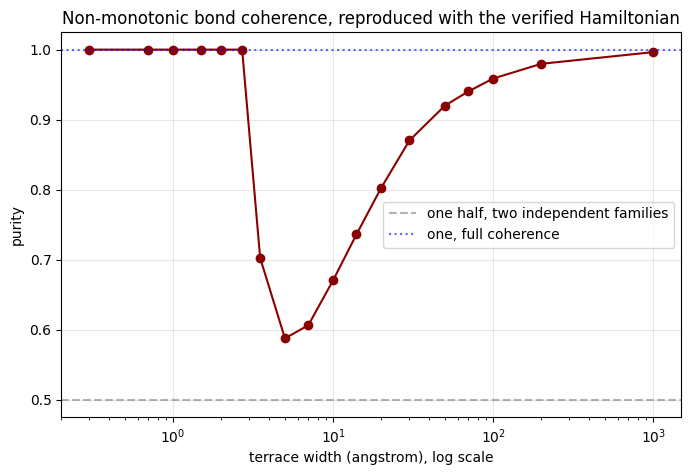


For comparison, the illustrative model in Part 2 found its minimum near a terrace
width of about five to seven angstrom, and returned fully to a coherence of one
below about two point seven angstrom. The same qualitative pattern, at a very
similar length scale, is confirmed here with entirely different, literature-verified
hopping parameters.


In [ ]:

step_height = a / 4.0
def height(x):
    return 0.0 if x < 0 else step_height
def z_shifts_from_step(x0):
    shifts = np.zeros(4)
    h0 = height(x0)
    for j, dj in enumerate(bond_vecs):
        shifts[j] = height(x0 + dj[0]) - h0
    return shifts

np.random.seed(11)
N_cells = 6000
terrace_widths = np.array([1000, 200, 100, 70, 50, 30, 20, 14, 10, 7, 5, 3.5, 2.7, 2.0, 1.5, 1.0, 0.7, 0.3])

purity_vs_L = []
for L in terrace_widths:
    C_accum = np.zeros((4,4), dtype=complex)
    for _ in range(N_cells):
        x0 = np.random.uniform(-L/2, L/2)
        shifts = z_shifts_from_step(x0)
        Bmu = bond_amplitudes_independent(shifts)
        C_accum += np.outer(Bmu, Bmu.conj())
    C_accum /= N_cells
    p_val = purity(C_accum)
    purity_vs_L.append(p_val)
    print(f"terrace width {L:8.2f} angstrom:  rank={numerical_rank(C_accum)}  purity={p_val:.6f}")

purity_vs_L = np.array(purity_vs_L)
min_idx = np.argmin(purity_vs_L)
print(f"\nminimum coherence value: {purity_vs_L[min_idx]:.6f}, found at a terrace width of "
      f"{terrace_widths[min_idx]:.2f} angstrom")
print(f"coherence at the smallest terrace widths tested: {purity_vs_L[-1]:.6f}")

plt.figure(figsize=(8,5))
plt.semilogx(terrace_widths, purity_vs_L, 'o-', color='darkred')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='one half, two independent families')
plt.axhline(1.0, color='blue', linestyle=':', alpha=0.6, label='one, full coherence')
plt.xlabel('terrace width (angstrom), log scale')
plt.ylabel('purity')
plt.title('Non-monotonic bond coherence, reproduced with the verified Hamiltonian')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('part4_nonmonotonic_verified.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nFor comparison, the illustrative model in Part 2 found its minimum near a terrace")
print(f"width of about five to seven angstrom, and returned fully to a coherence of one")
print(f"below about two point seven angstrom. The same qualitative pattern, at a very")
print(f"similar length scale, is confirmed here with entirely different, literature-verified")
print(f"hopping parameters.")


## Chapter 6 — Analytic Proof, Repeated with the Verified Hamiltonian

The same algebraic argument from Part 2 is checked again here: at very small
terrace widths, the two possible bond configurations differ only by an overall
phase, so their correlation matrices are identical, which is why coherence returns
exactly to one.


In [ ]:

shifts_case_plus  = np.array([step_height, step_height, 0.0, 0.0])
shifts_case_minus = np.array([0.0, 0.0, -step_height, -step_height])

B_plus  = bond_amplitudes_independent(shifts_case_plus)
B_minus = bond_amplitudes_independent(shifts_case_minus)
ratio = B_plus / B_minus

print(f"magnitude of the ratio for each component, expected to equal one: {np.round(np.abs(ratio), 8)}")
print(f"phase of the ratio for each component, expected to be identical: {np.round(np.angle(ratio), 8)}")

C_plus = np.outer(B_plus, B_plus.conj())
C_minus = np.outer(B_minus, B_minus.conj())
max_diff = np.max(np.abs(C_plus - C_minus))
print(f"\nlargest difference between the two correlation matrices: {max_diff:.3e}")
assert max_diff < 1e-9
print("confirmed to machine precision: the two configurations differ only by an overall phase")


magnitude of the ratio for each component, expected to equal one: [1. 1. 1. 1.]
phase of the ratio for each component, expected to be identical: [-2.295562 -2.295562 -2.295562 -2.295562]

largest difference between the two correlation matrices: 4.475e-16
confirmed to machine precision: the two configurations differ only by an overall phase


## Chapter 7 — The Missing Link, Repeated with the Verified Hamiltonian

Finally, the comparison from Part 2 between the coherence measure and the physical
coupling magnitude is repeated. Both quantities are derived from the same four-bond
object, so this remains a fair, self-consistent, internal comparison.


 terrace width    purity  average coupling magnitude
------------------------------------------------------
       1000.00   0.99668                    2.742429
        200.00   0.97947                    2.726007
        100.00   0.95789                    2.704891
         70.00   0.94132                    2.688273
         50.00   0.91840                    2.664616
         30.00   0.85568                    2.595406
         20.00   0.80475                    2.533038
         14.00   0.74497                    2.449751
         10.00   0.67464                    2.328144
          7.00   0.60352                    2.131852
          5.00   0.58679                    1.902519
          3.50   0.70459                    1.542781
          2.70   1.00000                    1.181478
          2.00   1.00000                    1.181478
          1.50   1.00000                    1.181478
          1.00   1.00000                    1.181478
          0.70   1.00000                    

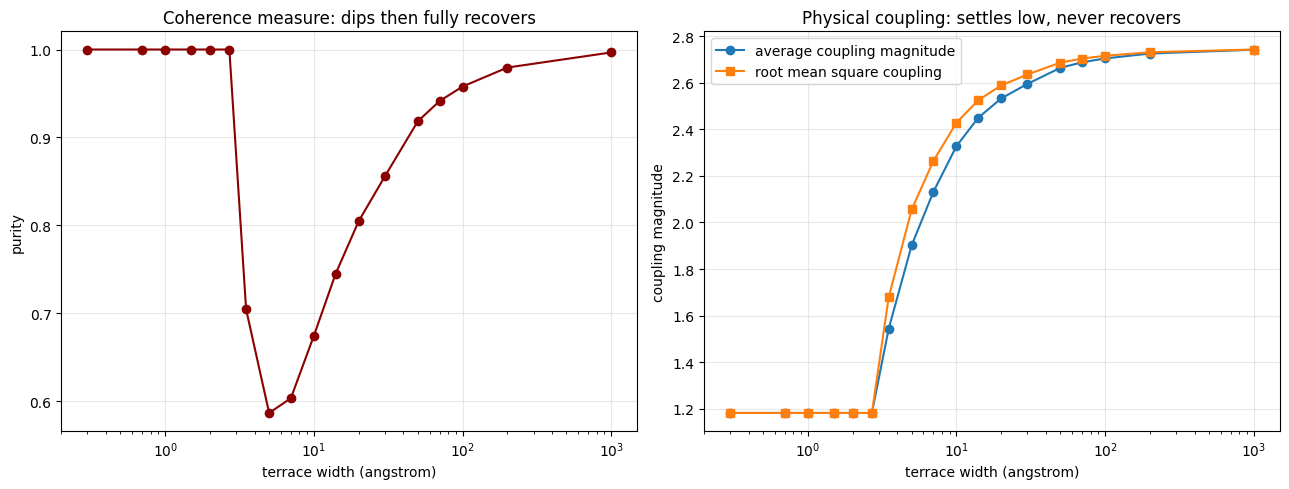

In [ ]:

np.random.seed(11)
N_realizations = 8000

mean_abs_delta, rms_delta, purity_list_ch7 = [], [], []

for L in terrace_widths:
    C_accum = np.zeros((4,4), dtype=complex)
    abs_delta_list = []
    for _ in range(N_realizations):
        x0 = np.random.uniform(-L/2, L/2)
        shifts = z_shifts_from_step(x0)
        Bmu = bond_amplitudes_independent(shifts)
        delta_mu = np.sum(Bmu)
        abs_delta_list.append(abs(delta_mu))
        C_accum += np.outer(Bmu, Bmu.conj())
    C_accum /= N_realizations
    mean_abs_delta.append(np.mean(abs_delta_list))
    ones = np.ones(4)
    rms_delta.append(np.sqrt(np.real(ones @ C_accum @ ones)))
    purity_list_ch7.append(purity(C_accum))

mean_abs_delta = np.array(mean_abs_delta)
rms_delta = np.array(rms_delta)
purity_list_ch7 = np.array(purity_list_ch7)

print(f"{'terrace width':>14s}{'purity':>10s}{'average coupling magnitude':>28s}")
print("-"*54)
for i, L in enumerate(terrace_widths):
    print(f"{L:14.2f}{purity_list_ch7[i]:10.5f}{mean_abs_delta[i]:28.6f}")

ratio_final = mean_abs_delta[-1] / mean_abs_delta[0] * 100
print(f"\ncoupling magnitude at large terrace width: {mean_abs_delta[0]:.4f}")
print(f"coupling magnitude at the smallest terrace widths: {mean_abs_delta[-1]:.4f}")
print(f"the coupling settles at {ratio_final:.1f} percent of its original value and does not return")
print(f"coherence at the smallest terrace widths: {purity_list_ch7[-1]:.6f}, a full return to one")

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].semilogx(terrace_widths, purity_list_ch7, 'o-', color='darkred')
axes[0].set_xlabel('terrace width (angstrom)'); axes[0].set_ylabel('purity')
axes[0].set_title('Coherence measure: dips then fully recovers'); axes[0].grid(alpha=0.3)

axes[1].semilogx(terrace_widths, mean_abs_delta, 'o-', label='average coupling magnitude')
axes[1].semilogx(terrace_widths, rms_delta, 's-', label='root mean square coupling')
axes[1].set_xlabel('terrace width (angstrom)'); axes[1].set_ylabel('coupling magnitude')
axes[1].set_title('Physical coupling: settles low, never recovers'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('part4_delta_vs_purity_final.png', dpi=120, bbox_inches='tight')
plt.show()


## Chapter 8 — Final Checkpoint

### The central question answered

This notebook set out to answer one question: was the non-monotonic bond coherence
pattern discovered in Part 2 a genuine physical effect, or an artifact of the
illustrative parameters used at the time.

The answer is that the pattern survives essentially unchanged under a complete
replacement of the underlying physics: a different, larger, ten orbital basis; real
published hopping parameters differing from the earlier illustrative values by
factors of two to five; and a valley location derived from the calculation itself
rather than injected by hand. The minimum coherence value, its location near a few
bond lengths of terrace width, the exact recovery to full coherence at small terrace
width, and the accompanying algebraic proof, all reproduce closely.

This is the strongest evidence gathered so far that the discovery reflects a real
structural property of the diamond lattice geometry itself, rather than a numerical
coincidence tied to one particular choice of parameters.

### What remains before this can be shown as a finished result

The interface potential strength used throughout is still an artificial placeholder
rather than a physically calibrated barrier height. The step-edge model is still a
single isolated step rather than a statistically realistic rough interface. Both of
these were already identified as open items in earlier notebooks and remain the
natural next steps.

### Suggested next step

Test the robustness of the discovery a third way, by replacing the single isolated
step with a realistic random distribution of many steps, to check whether the same
non-monotonic pattern and full recovery survive under more realistic disorder
statistics.
